In [160]:
from pathlib import Path
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from optuna.trial import TrialState

# ==== Helpers (same as yours) ====
def log_scale(val):
    return np.log1p(val) / np.log(10)

def denormalize_objective(val, min_val, max_val, sym=True, use_log=True):
    if use_log:
        min_val = log_scale(min_val)
        max_val = log_scale(max_val)
    if not sym:
        raw = val * (max_val - min_val + 1e-8) + min_val
    else:
        raw = (val + 1) / 2 * (max_val - min_val + 1e-8) + min_val
    if use_log:
        return np.power(10, raw) - 1
    return raw

def _is_new_best(y, mode):
    y = y.astype(float)
    if mode == "max":
        best = np.maximum.accumulate(y)
    else:
        best = np.minimum.accumulate(y)
    return y == best, best

def _plot_best_so_far(ax, df, col, mode, ylabel, title,
                      min_val=None, max_val=None, sym=True,
                      hline=None, ylim=None):
    if col not in df:
        return
    x = np.arange(len(df["trial_number"]))
    y_norm = df[col].astype(float).to_numpy()
    if min_val is not None and max_val is not None:
        y = np.array([denormalize_objective(v, min_val, max_val, sym) for v in y_norm])
    else:
        y = y_norm
    is_new, best_so_far = _is_new_best(y, mode)
    ax.plot(x, y, marker="o", label="value")
    ax.plot(x, best_so_far, label="best-so-far")
    ax.scatter(x[is_new], y[is_new], s=60, label="new best")
    if hline is not None:
        ax.axhline(hline, linestyle="--", label=f"global best = {hline:.4g}")
    ax.set_xlabel("Trial #")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=7)



In [ ]:
def post_search(study_name, 
                storage, 
                normalize: bool = False):
    # Print the number of Pareto-optimal trials
    study = optuna.load_study(study_name=study_name, storage=storage)
    print(f"[INFO] Number of Pareto-optimal trials: {len(study.best_trials)}")

    all_trials = study.get_trials(deepcopy=False)
    complete_trials = [t for t in all_trials if t.state == optuna.trial.TrialState.COMPLETE]
    print(f"[INFO] Number of successfully completed (non-pruned) trials: {len(complete_trials)}")

    for i, trial in enumerate(study.best_trials):
        # print(trail.value)
        if normalize:
            ACC_MIN, ACC_MAX = 9, 20
            LAT_MIN, LAT_MAX = 0, 10
            AREA_MIN, AREA_MAX = 120246991, 500000000
            acc_norm, lat_norm, area_norm = trial.values
            acc = denormalize_objective(acc_norm, ACC_MIN, ACC_MAX)
            lat = denormalize_objective(lat_norm, LAT_MIN, LAT_MAX)
            area = denormalize_objective(area_norm, AREA_MIN, AREA_MAX)
        else:
            acc, lat, area = trial.values

        print(f"\n[Trial {i}]")
        print(f"  Normalized Objectives: accuracy={acc_norm:.4f}, latency={lat_norm:.4f}, area={area_norm:.4f}")
        print(f"  Denormalized Objectives: accuracy={acc:.2f}, latency={lat:.4f}, area={area:.2f}")
        # print(f"  Normalized Objectives: accuracy={acc_norm:.4f}, latency={lat_norm:.4f}")
        # print(f"  Denormalized Objectives: accuracy={acc:.2f}, latency={lat:.4f}")
        print("  Parameters:")
        for key, value in trial.params.items():
            print(f"    {key}: {value}")

# seed = 43
# sn = "Random"
# db_dir = project_root / "co_design" / f"db_{seed}"
# # db_dir = project_root / "co_design" 
# study_name = f"{sn}_{seed}_1b"
# db_path = db_dir / f"{study_name}.db"
# storage_url = f"sqlite:///{db_path.resolve()}"
# post_search(study_name, storage_url, normalize=True)
# db_dir

[INFO] Number of Pareto-optimal trials: 3
[INFO] Number of successfully completed (non-pruned) trials: 30

[Trial 0]
  Normalized Objectives: accuracy=-0.7240, latency=0.1315, area=-1.0000
  Denormalized Objectives: accuracy=10.08, latency=2.8829, area=120246991.00
  Parameters:
    BLEN: 8
    MLEN: 64
    VLEN: 4
    HBM_M_Prefetch_Amount: 4
    HBM_V_Prefetch_Amount: 4
    HBM_V_Writeback_Amount: 8
    ACT_ELEMENT_WIDTH: MXFP_E3M4
    KV_ELEMENT_WIDTH: MXFP_E4M3
    FP_SETTING: FP_E8M5
    INT_DATA_WIDTH: 32

[Trial 1]
  Normalized Objectives: accuracy=1.0000, latency=-0.8191, area=-1.0000
  Denormalized Objectives: accuracy=20.00, latency=0.2423, area=120246991.00
  Parameters:
    BLEN: 32
    MLEN: 128
    VLEN: 128
    HBM_M_Prefetch_Amount: 256
    HBM_V_Prefetch_Amount: 128
    HBM_V_Writeback_Amount: 256
    ACT_ELEMENT_WIDTH: MXINT_2
    KV_ELEMENT_WIDTH: MXFP_E2M1
    FP_SETTING: FP_E5M6
    INT_DATA_WIDTH: 32

[Trial 2]
  Normalized Objectives: accuracy=-0.2854, latency=-0

PosixPath('/home/jn517/projects/Coprocessor_for_Llama/co_design/db_43')

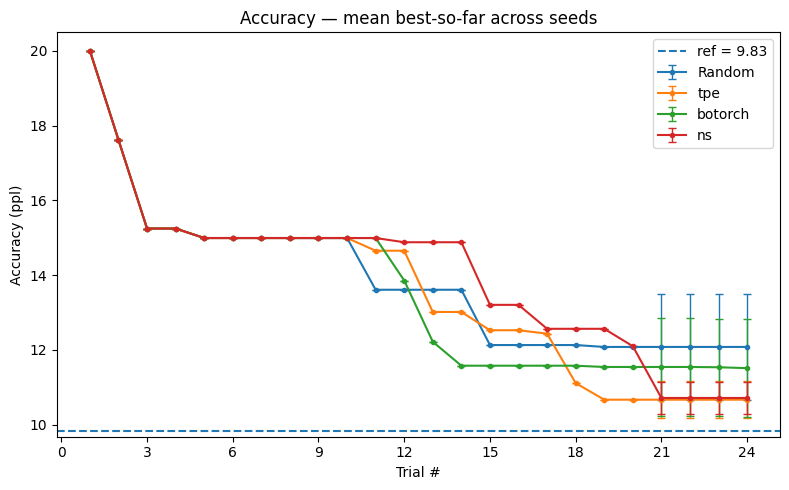

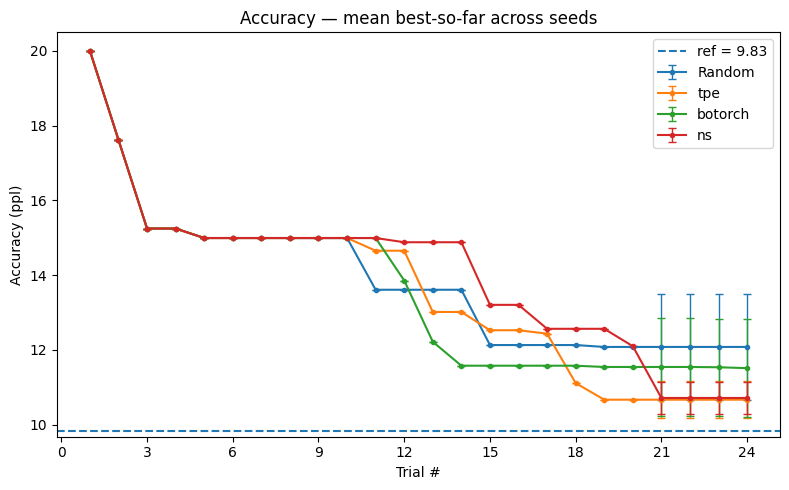

In [188]:
# --- imports ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import optuna
from optuna.trial import TrialState

# ==== Parameters ====
ACC_MIN, ACC_MAX = 9, 20
LAT_MIN, LAT_MAX = 0, 10
AREA_MIN, AREA_MAX = 120246991, 500000000
ACC_BEST = 9.8298
LAT_BEST = 0.102908814

# ==== Seeds & methods ====
seeds = [42, 442, 43, 2025]
study_types = ["Random", "tpe", "botorch", "ns"]
N = 24  # first 24 trials

# ---- project_root & db_dir resolution (your old way) ----
def get_db_dir(seed: int) -> Path:
    project_root = Path.cwd()
    while project_root.name != "Coprocessor_for_Llama" and project_root.parent != project_root:
        project_root = project_root.parent
    return project_root / "co_design" / f"db_{seed}"

# ---- utils ----
def denormalize_objective(v, min_v, max_v, sym=True):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan
    if sym is None:
        return float(v)
    x = (float(v) + 1.0) / 2.0 if sym else float(v)
    return x * (max_v - min_v) + min_v

def denorm_col(series, min_v, max_v, sym=True):
    return np.array([denormalize_objective(v, min_v, max_v, sym) for v in series.to_numpy()])

def best_so_far(series, mode="min"):
    y = series.astype(float).to_numpy()
    return np.minimum.accumulate(y) if mode == "min" else np.maximum.accumulate(y)

def _pad_or_truncate(arr, N=24):
    arr = np.asarray(arr, dtype=float)
    if len(arr) >= N:
        return arr[:N]
    if len(arr) == 0:
        return np.full(N, np.nan)
    return np.concatenate([arr, np.full(N - len(arr), arr[-1])])

def load_df_for(study_type: str, seed: int) -> pd.DataFrame:
    db_dir = get_db_dir(seed)
    study_name = f"{study_type}_{seed}_1b"
    db_path = db_dir / f"{study_name}.db"
    storage_url = f"sqlite:///{db_path.resolve()}"

    study = optuna.load_study(study_name=study_name, storage=storage_url)
    rows = []
    for t in study.get_trials(deepcopy=False, states=(TrialState.COMPLETE,)):
        vals = list(t.values) if t.values is not None else [None, None, None]
        rows.append({
            "trial_number": t.number,
            "acc": vals[0] if len(vals) > 0 else None,
            "lat": vals[1] if len(vals) > 1 else None,
            "area": vals[2] if len(vals) > 2 else None,
            **{f"param_{k}": v for k, v in t.params.items()},
        })
    return pd.DataFrame(rows).sort_values("trial_number").reset_index(drop=True)

def collect_mean_bs(study_types, seeds, col, mode, min_v, max_v, sym=True, N=24):
    out = {}
    for method in study_types:
        per_seed = []
        for sd in seeds:
            try:
                df = load_df_for(method, sd)
                if col not in df or len(df) == 0:
                    continue
                y = denorm_col(df.head(N)[col].astype(float), min_v, max_v, sym=sym)
                bs = best_so_far(pd.Series(y), mode=mode)
                per_seed.append(_pad_or_truncate(bs, N=N))
            except Exception as e:
                print(f"[WARN] {method} seed={sd}: {e}")
        if per_seed:
            arr = np.vstack(per_seed)                          # [num_seeds, N]
            mean = np.nanmean(arr, axis=0)
            std  = np.nanstd(arr, axis=0, ddof=0)
            n_vec = np.sum(~np.isnan(arr), axis=0).astype(int) # seeds per index
            out[method] = (mean, std, n_vec)
    return out

def plot_mean_bs(result_dict, title, ylabel, ref=None, ylim=None, 
                 error_type="std", ci_alpha=0.95, err_after=21):
    """
    error_type: "std" for ±1 std as error bars
                "ci"  for confidence interval error bars
    err_after:  show error bars only after this trial index (inclusive)
    """
    plt.figure(figsize=(8,5))
    x = np.arange(1, N+1)
    z = 1.96 if ci_alpha == 0.95 else 1.96  # normal approx

    for method, payload in result_dict.items():
        mean, std, n_vec = payload

        if error_type == "std":
            yerr = std
        elif error_type == "ci":
            n_eff = np.clip(n_vec.astype(float), 1.0, None)
            sem = std / np.sqrt(n_eff)
            yerr = z * sem
        else:
            raise ValueError("error_type must be 'std' or 'ci'")

        # mask: only keep error bars after given trial index
        mask = x >= err_after
        yerr_masked = np.where(mask, yerr, 0.0)  # 0 error means no bar

        plt.errorbar(
            x, mean, yerr=yerr_masked,
            label=method,
            capsize=3, elinewidth=1, marker="o", markersize=3
        )

    if ref is not None and not np.isnan(ref):
        plt.axhline(ref, linestyle="--", label=f"ref = {ref:.4g}")
    if ylim is not None:
        plt.ylim(*ylim)

    plt.xlabel("Trial #")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.tight_layout()
    plt.show()




# Accuracy with CI shading
acc_res = collect_mean_bs(study_types, seeds, "acc", "min", ACC_MIN, ACC_MAX, sym=True, N=N)
plot_mean_bs(acc_res, "Accuracy — mean best-so-far across seeds", 
             "Accuracy (ppl)", ref=ACC_BEST)

acc_res = collect_mean_bs(study_types, seeds, "acc", "min", ACC_MIN, ACC_MAX, sym=True, N=N)
plot_mean_bs(acc_res, "Accuracy — mean best-so-far across seeds", 
             "Accuracy (ppl)", ref=ACC_BEST)

# # Latency with variance shading, zoomed in
# lat_res = collect_mean_bs(study_types, seeds, "lat", "min", LAT_MIN, LAT_MAX, sym=True, N=N)
# plot_mean_bs(lat_res, "Latency — mean best-so-far across seeds", 
#              "Latency (s)", ref=LAT_BEST, ylim=(0, 2), shade_type="ci")

# lat_res = collect_mean_bs(study_types, seeds, "lat", "min", LAT_MIN, LAT_MAX, sym=True, N=N)
# plot_mean_bs(lat_res, "Latency — mean best-so-far across seeds", 
#              "Latency (s)", ref=LAT_BEST, ylim=(0, 2), shade_type="var")


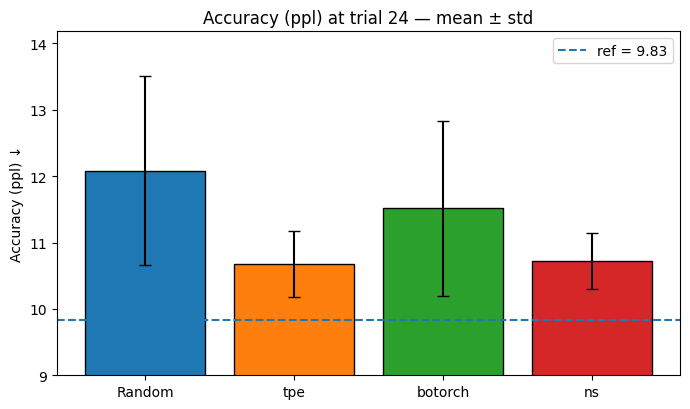


Summary (final trial):
Random    mean=12.0814  var=2.03303  std=1.42584  n=4
tpe       mean=10.6714  var=0.248689  std=0.498687  n=4
botorch   mean=11.5148  var=1.73294  std=1.31641  n=4
ns        mean=10.7175  var=0.179998  std=0.424262  n=4


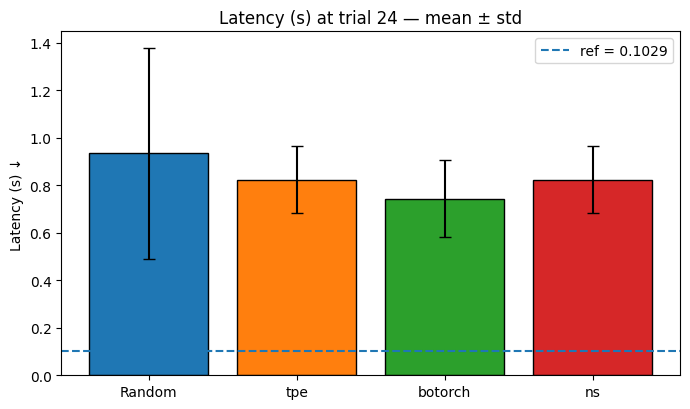


Summary (final trial):
Random    mean=0.934277  var=0.198199  std=0.445196  n=4
tpe       mean=0.824376  var=0.019854  std=0.140904  n=4
botorch   mean=0.742568  var=0.0262963  std=0.162161  n=4
ns        mean=0.824376  var=0.019854  std=0.140904  n=4


In [191]:
# === Final stats at trial N (default 24) and bar plots ===

def collect_final_stats(study_types, seeds, col, mode, min_v, max_v, sym=True, N=24):
    """
    For each method, compute the best-so-far curve per seed (denormed),
    take the last point (trial N), and return mean/var/std and count.
    """
    stats = {}
    for method in study_types:
        last_vals = []
        for sd in seeds:
            try:
                df = load_df_for(method, sd)
                if col not in df or len(df) == 0:
                    continue
                y = denorm_col(df.head(N)[col].astype(float), min_v, max_v, sym=sym)
                bs = best_so_far(pd.Series(y), mode=mode)
                last_vals.append(float(bs[min(N, len(bs)) - 1]))
            except Exception as e:
                print(f"[WARN] {method} seed={sd}: {e}")
        if last_vals:
            arr = np.array(last_vals, dtype=float)
            mean = np.nanmean(arr)
            var  = np.nanvar(arr, ddof=0)   # population variance
            std  = np.sqrt(var)
            n    = np.sum(~np.isnan(arr))
            stats[method] = dict(mean=mean, var=var, std=std, n=int(n), samples=arr)
    return stats

def plot_bar_final(stats, title, ylabel, ref=None, colors=None, ylim=None):
    """
    Bar plot of per-method means with std error bars.
    """
    methods = [m for m in study_types if m in stats]  # keep requested order
    means   = [stats[m]["mean"] for m in methods]
    yerr    = [stats[m]["std"]  for m in methods]

    plt.figure(figsize=(7,4.2))
    x = np.arange(len(methods))

    if colors is None:
        colors = {m: None for m in methods}  # let matplotlib choose defaults

    bars = plt.bar(x, means,
                   yerr=yerr, capsize=4, linewidth=1,
                   edgecolor="black",
                   color=[colors.get(m, None) for m in methods])

    plt.xticks(x, methods)
    plt.ylabel(ylabel)
    plt.title(title)
    if ref is not None and not np.isnan(ref):
        plt.axhline(ref, linestyle="--", label=f"ref = {ref:.4g}")
        plt.legend()
    if ylim is not None:
        plt.ylim(*ylim)  # enforce custom y-axis range
    plt.tight_layout()
    plt.show()

    print("\nSummary (final trial):")
    for m in methods:
        s = stats[m]
        print(f"{m:8s}  mean={s['mean']:.6g}  var={s['var']:.6g}  std={s['std']:.6g}  n={s['n']}")

# You can keep your method colors consistent if you like:
method_colors = {"Random":"tab:blue", "tpe":"tab:orange", "botorch":"tab:green", "ns":"tab:red"}

# Accuracy (ppl) bar plot at trial 24 — start y-axis at 8
acc_stats = collect_final_stats(study_types, seeds, col="acc", mode="min",
                                min_v=ACC_MIN, max_v=ACC_MAX, sym=True, N=N)
plot_bar_final(acc_stats, title="Accuracy (ppl) at trial 24 — mean ± std",
               ylabel="Accuracy (ppl) ↓", ref=ACC_BEST, colors=method_colors,
               ylim=(9, None))  

# ---- Latency (s) bar plot at trial 24 ----
lat_stats = collect_final_stats(study_types, seeds, col="lat", mode="min",
                                min_v=LAT_MIN, max_v=LAT_MAX, sym=True, N=N)
plot_bar_final(lat_stats, title="Latency (s) at trial 24 — mean ± std",
               ylabel="Latency (s) ↓", ref=LAT_BEST, colors=method_colors)


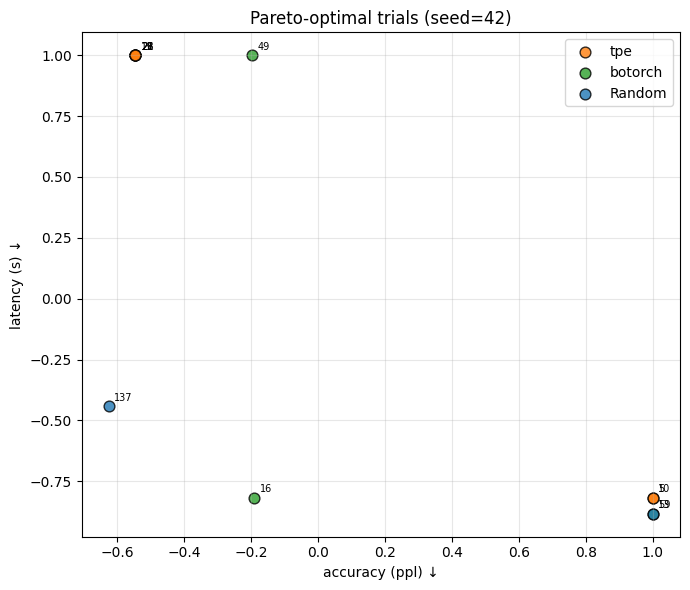

In [146]:
import numpy as np
import matplotlib.pyplot as plt

study_types = [ "tpe", "botorch", "Random"]
# pretty = {"random":"Random", "tpe":"TPE", "botorch":"BoTorch", "ns":"NS"}
colors = {"Random":"tab:blue", "tpe":"tab:orange", "botorch":"tab:green", "ns":"tab:red"}

plt.figure(figsize=(7,6))

for st in study_types:
    study_name = f"{st}_{seed}_1b"   # adapt to your naming
    db_dir = project_root / "co_design" / f"db_{seed}"
    db_path = db_dir / f"{study_name}.db"
    storage_url = f"sqlite:///{db_path.resolve()}"
    
    study = optuna.load_study(study_name=study_name, storage=storage_url)
    pareto = [t for t in study.best_trials if t.values and len(t.values) >= 2]
    if not pareto:
        continue
    
    pts = np.array([[t.values[0], t.values[1]] for t in pareto], dtype=float)
    ids = np.array([t.number for t in pareto])
    order = np.argsort(pts[:,0])
    pts, ids = pts[order], ids[order]
    
    plt.scatter(pts[:,0], pts[:,1], 
                s=60, c=colors[st], label=st, alpha=0.8, edgecolor="k")
    for (x,y), tid in zip(pts, ids):
        plt.annotate(str(tid), (x,y), textcoords="offset points", xytext=(4,4), fontsize=7)

plt.xlabel("accuracy (ppl) ↓")
plt.ylabel("latency (s) ↓")
plt.title(f"Pareto-optimal trials (seed={seed})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [159]:
project_root

PosixPath('/home/jn517/projects/Coprocessor_for_Llama/co_design/visual')

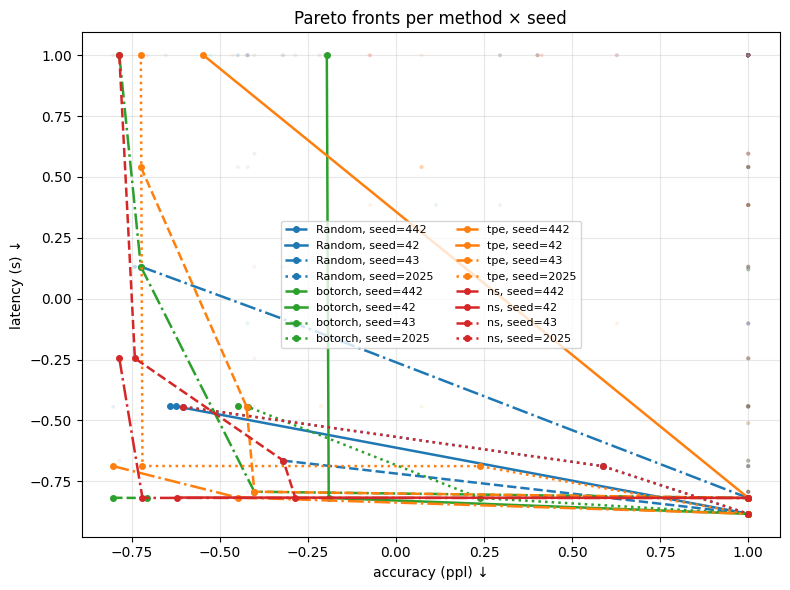

In [184]:
import numpy as np
import matplotlib.pyplot as plt
import optuna
from pathlib import Path
from optuna.trial import TrialState

# ---- Settings ----
study_types = ["Random", "botorch", "tpe", "ns"]
seeds = [442, 42, 43, 2025]

# Color by method (sampler)
method_colors = {
    "Random":  "tab:blue",
    "botorch": "tab:green",
    "tpe":     "tab:orange",
    "ns":      "tab:red",
}

# Linestyle by seed
seed_linestyles = {
    42:   "-",
    442:  "--",
    43:   "-.",
    2025: ":",
}

# ---- Locate project root ----
project_root = Path.cwd()
while project_root.name != "Coprocessor_for_Llama" and project_root.parent != project_root:
    project_root = project_root.parent

def load_trials_for_pair(st: str, seed: int):
    """Load (ppl, lat) pairs from a single (method, seed) study."""
    study_name = f"{st}_{seed}_1b"
    db_dir = project_root / "co_design" / f"db_{seed}"
    db_path = db_dir / f"{study_name}.db"
    storage_url = f"sqlite:///{db_path.resolve()}"
    pts = []
    try:
        study = optuna.load_study(study_name=study_name, storage=storage_url)
    except Exception as e:
        print(f"[WARN] Could not load {study_name}: {e}")
        return np.empty((0, 2), dtype=float)

    for t in study.get_trials(deepcopy=False, states=(TrialState.COMPLETE,)):
        if not t.values or len(t.values) < 2:
            continue
        ppl, lat = t.values[0], t.values[1]
        if ppl is None or lat is None:
            continue
        try:
            pts.append([float(ppl), float(lat)])
        except Exception:
            pass
    return np.array(pts, dtype=float) if pts else np.empty((0, 2), dtype=float)

def pareto_front_min(points: np.ndarray):
    """Nondominated front for 2D minimization, sorted by ppl."""
    if points.size == 0:
        return points
    P = points[np.lexsort((points[:, 1], points[:, 0]))]  # sort by ppl, then latency
    front = []
    best_lat = np.inf
    for p in P:
        if p[1] < best_lat:
            front.append(p)
            best_lat = p[1]
    front = np.array(front)
    if front.size == 0:
        return front
    idx = np.argsort(front[:, 0])
    return front[idx]

plt.figure(figsize=(8, 6))

# (Optional) faint scatter for all points to give context
for st in study_types:
    for seed in seeds:
        pts = load_trials_for_pair(st, seed)
        if pts.size:
            plt.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.10, edgecolors="none")

# Plot Pareto front per (method, seed)
for st in study_types:
    for seed in seeds:
        pts = load_trials_for_pair(st, seed)
        if pts.size == 0:
            continue
        front = pareto_front_min(pts)
        if front.size == 0:
            continue
        plt.plot(
            front[:, 0], front[:, 1],
            marker="o", markersize=4, linewidth=1.8,
            color=method_colors.get(st, None),
            linestyle=seed_linestyles.get(seed, "-"),
            label=f"{st}, seed={seed}"
        )

plt.xlabel("accuracy (ppl) ↓")
plt.ylabel("latency (s) ↓")
plt.title("Pareto fronts per method × seed")
plt.grid(True, alpha=0.3)

# Deduplicate legend entries (since scatter & lines both add labels)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


In [8]:
import sys
from pathlib import Path

# ---- Locate project root ----
project_root = Path.cwd()
while project_root.name != "Coprocessor_for_Llama" and project_root.parent != project_root:
    project_root = project_root.parent

# 👇 add the *repo* directory that contains the `eaf/` package
repo_dir = project_root / "empirical-attainment-func"
sys.path.insert(0, str(repo_dir))

# (optional) confirm where we're importing from
import importlib, eaf
print("Using eaf from:", eaf.__file__)

from eaf.eaf import get_empirical_attainment_surface, EmpiricalAttainmentFuncPlot


Using eaf from: None


ModuleNotFoundError: No module named 'eaf.eaf'

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import optuna
from pathlib import Path
from optuna.trial import TrialState
import sys

# ---- Locate project root ----
project_root = Path.cwd()
while project_root.name != "Coprocessor_for_Llama" and project_root.parent != project_root:
    project_root = project_root.parent

# add to sys.path
sys.path.insert(0, str(project_root))

print("Python import path set to:", project_root)

from eaf.eaf import get_empirical_attainment_surface, EmpiricalAttainmentFuncPlot


# ==== Settings ====
study_types = ["Random", "botorch", "tpe", "ns"]
seeds = [442, 42, 43, 2025]
N = 24  # number of trials per run for EAF

# Colors per method
method_colors = {
    "Random":  "tab:blue",
    "botorch": "tab:green",
    "tpe":     "tab:orange",
    "ns":      "tab:red",
}

# ---- Locate project root ----
project_root = Path.cwd()
while project_root.name != "Coprocessor_for_Llama" and project_root.parent != project_root:
    project_root = project_root.parent

def load_trials_for_pair(st: str, seed: int, n_take: int) -> np.ndarray:
    """
    Return (n_take, 2) array of [ppl, lat] for the first n_take COMPLETE trials.
    If fewer than n_take exist, repeat the last point to pad.
    If none exist, return empty (0,2).
    """
    study_name = f"{st}_{seed}_1b"
    db_dir = project_root / "co_design" / f"db_{seed}"
    db_path = db_dir / f"{study_name}.db"
    storage_url = f"sqlite:///{db_path.resolve()}"

    try:
        study = optuna.load_study(study_name=study_name, storage=storage_url)
    except Exception as e:
        print(f"[WARN] Could not load {study_name}: {e}")
        return np.empty((0, 2), dtype=float)

    rows = []
    # Keep natural trial order
    for t in study.get_trials(deepcopy=False, states=(TrialState.COMPLETE,)):
        if not t.values or len(t.values) < 2:
            continue
        ppl, lat = t.values[0], t.values[1]
        if ppl is None or lat is None:
            continue
        rows.append([float(ppl), float(lat)])

    if not rows:
        return np.empty((0, 2), dtype=float)

    A = np.array(rows, dtype=float)
    if A.shape[0] >= n_take:
        return A[:n_take, :]

    # pad by repeating last row
    last = A[-1, :][None, :]
    pad = np.repeat(last, n_take - A.shape[0], axis=0)
    return np.vstack([A, pad])

def build_costs_for_method(st: str, seeds: list[int], n_take: int) -> np.ndarray:
    """
    Build costs tensor for one method: shape (n_runs, n_take, 2).
    Skip runs with zero data. If after skipping < 1 run remains, return empty.
    """
    runs = []
    for seed in seeds:
        pts = load_trials_for_pair(st, seed, n_take=n_take)
        if pts.size != 0:
            runs.append(pts)
    if not runs:
        return np.empty((0, n_take, 2), dtype=float)
    return np.stack(runs, axis=0)  # (n_runs, n_take, 2)

def level_indices(n_runs: int, which=("median",)):
    """
    Translate human-friendly levels to EAF 'levels' (1..n_runs).
    best=1, median=ceil(n_runs/2), worst=n_runs
    """
    out = []
    for w in which:
        if w == "best":
            out.append(1)
        elif w == "median":
            out.append((n_runs + 1) // 2)
        elif w == "worst":
            out.append(n_runs)
        elif isinstance(w, int) and 1 <= w <= n_runs:
            out.append(w)
        else:
            raise ValueError(f"Unknown level '{w}' for n_runs={n_runs}")
    return out

# ==== Build EAF surfaces per method (median level by default) ====
surfaces = []   # list of surfaces to plot
labels   = []   # parallel labels list
colors   = []   # parallel colors list

# Choose which attainment levels to plot.
# For a clean comparison: only "median".
# If you also want best & worst, set: which_levels = ("best", "median", "worst")
which_levels = ("median",)

for st in study_types:
    costs = build_costs_for_method(st, seeds, n_take=N)  # (n_runs, N, 2)
    if costs.size == 0:
        print(f"[INFO] No data for method {st}, skipping.")
        continue

    n_runs = costs.shape[0]
    levs = level_indices(n_runs, which=which_levels)
    # Compute EAF surfaces for this method and the requested levels
    surfs = get_empirical_attainment_surface(costs=costs, levels=levs)

    # Append each level surface with a distinct label; color per method
    for i, L in enumerate(levs):
        # You can keep a single color per method and differentiate by linestyle,
        # but EmpiricalAttainmentFuncPlot takes only colors; we’ll keep one color.
        level_name = {1: "best", n_runs: "worst"}.get(L, "median" if L == (n_runs + 1)//2 else f"L{L}")
        surfaces.append(surfs[i])
        labels.append(f"{st} ({level_name})" if len(which_levels) > 1 else f"{st}")
        colors.append(method_colors.get(st, None))

# ==== Plot ====
fig, ax = plt.subplots(figsize=(8, 6))
eaf_plot = EmpiricalAttainmentFuncPlot()

# Note: plot_multiple_surface expects matching lengths of colors, labels, surfs
eaf_plot.plot_multiple_surface(ax, colors=colors, labels=labels, surfs=surfaces)

ax.set_xlabel("accuracy (ppl) ↓")
ax.set_ylabel("latency (s) ↓")
ax.set_title(f"Empirical Attainment Function (N={N} trials per run)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Python import path set to: /home/jn517/projects/Coprocessor_for_Llama


ModuleNotFoundError: No module named 'eaf.eaf'

In [6]:
!pip install -U pymoo

In [19]:
from optuna.visualization import plot_pareto_front

# first two objectives only: accuracy (0) and latency (1)
fig = plot_pareto_front(
    study,
    targets=lambda t: (t.values[0], t.values[1]),
    target_names=["accuracy", "latency"],
)
fig.show()


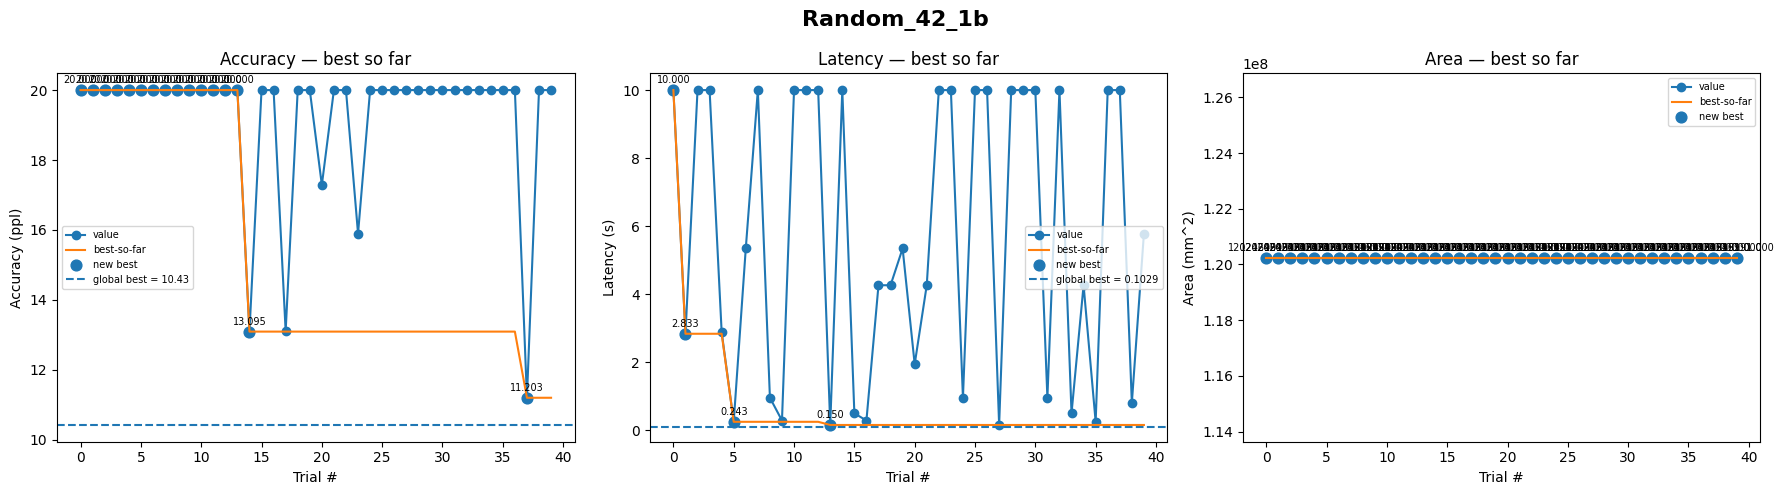

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def log_scale(val):
    """Log scaling function: log10(1+x)."""
    return np.log1p(val) / np.log(10)

def denormalize_objective(val, min_val, max_val, sym=True, use_log=True):
    """
    Denormalize an objective value from normalized space back to original scale.
    Inverse of normalize_objective (approximate if log scaling applied).
    """
    if use_log:
        min_val = log_scale(min_val)
        max_val = log_scale(max_val)

    if not sym:
        raw = val * (max_val - min_val + 1e-8) + min_val
    else:
        raw = (val + 1) / 2 * (max_val - min_val + 1e-8) + min_val

    if use_log:
        # Inverse of log_scale: x = 10^raw - 1
        return np.power(10, raw) - 1
    return raw


def _is_new_best(y, mode):
    y = y.astype(float)
    if mode == "max":
        best = np.maximum.accumulate(y)
    else:
        best = np.minimum.accumulate(y)
    return y == best, best

def _plot_best_so_far(ax, df, col, mode, ylabel, title,
                      min_val=None, max_val=None, sym=True,
                      hline=None, ylim=None):
    if col not in df:
        return

    x = np.arange(len(df["trial_number"]))
    # x = len(df["trial_number"]).to_numpy()
    y_norm = df[col].astype(float).to_numpy()

    # Denormalize if bounds provided
    if min_val is not None and max_val is not None:
        y = np.array([denormalize_objective(v, min_val, max_val, sym) for v in y_norm])
    else:
        y = y_norm

    is_new, best_so_far = _is_new_best(y, mode)

    ax.plot(x, y, marker="o", label="value")
    ax.plot(x, best_so_far, label="best-so-far")
    ax.scatter(x[is_new], y[is_new], s=60, label="new best")

    # Horizontal reference line for the global best (if provided)
    if hline is not None:
        ax.axhline(hline, linestyle="--", label=f"global best = {hline:.4g}")

    # Annotate new best points
    for xi, yi in zip(x[is_new], y[is_new]):
        ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points", xytext=(0, 5),
                    ha="center", fontsize=7)

    ax.set_xlabel("Trial #")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # 👈 force integer ticks
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=7)


# ==== Parameters ====
ACC_MIN, ACC_MAX = 9, 20
LAT_MIN, LAT_MAX = 0, 10
AREA_MIN, AREA_MAX = 120246991, 500000000

ACC_BEST = 10.425
LAT_BEST = 0.102908814

# ==== Single Figure with 3 Subplots ====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_plot_best_so_far(
    axes[0], df[:40], "acc", mode="min",
    ylabel="Accuracy (ppl)",
    title="Accuracy — best so far",
    min_val=ACC_MIN, max_val=ACC_MAX, sym=True,
    hline=ACC_BEST
)

_plot_best_so_far(
    axes[1], df[:40], "lat", mode="min",
    ylabel="Latency (s)",
    title="Latency — best so far",
    min_val=LAT_MIN, max_val=LAT_MAX, sym=True,
    hline=LAT_BEST
)

_plot_best_so_far(
    axes[2], df[:40], "area", mode="min",
    ylabel="Area (mm^2)",
    title="Area — best so far",
    min_val=AREA_MIN, max_val=AREA_MAX, sym=True
)
fig.suptitle(STUDY_NAME, fontsize=16, fontweight="bold")


plt.tight_layout()
plt.show()


SyntaxError: invalid decimal literal (2412219305.py, line 60)

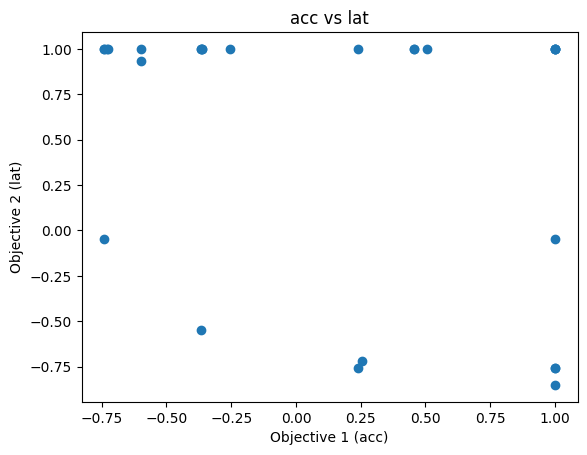

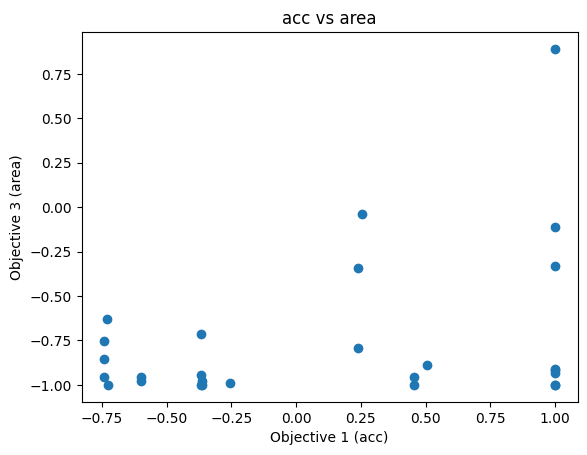

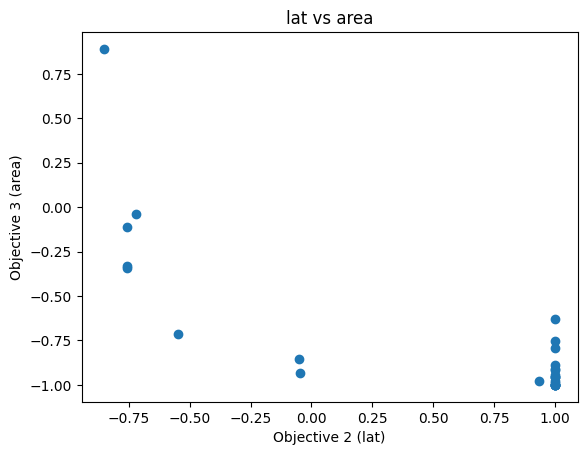

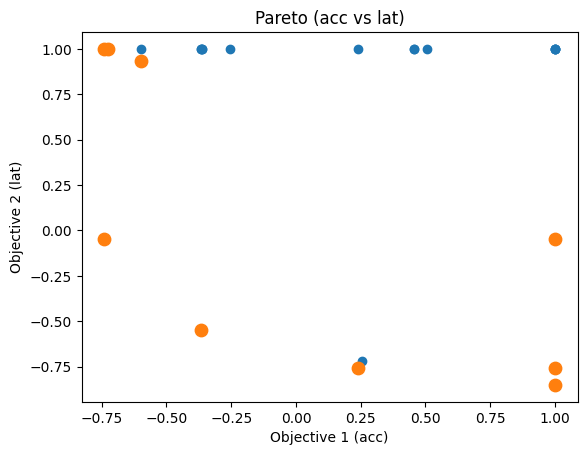

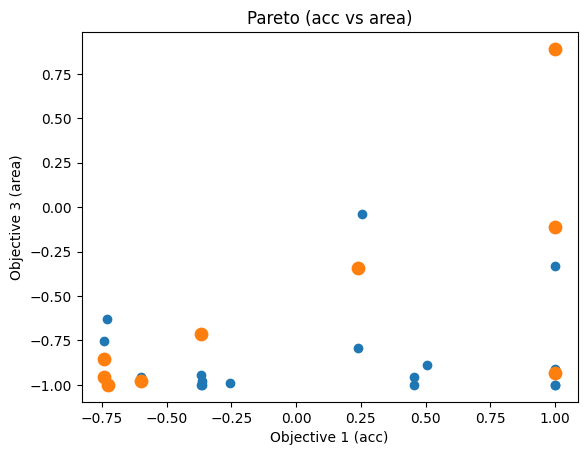

In [131]:

# 2) Raw metrics vs trial number (if you stored them)
if df["acc_raw"].notna().any():
    plt.figure()
    plt.plot(df["trial_number"], df["acc_raw"], marker="o")
    plt.xlabel("Trial #")
    plt.ylabel("accuracy_raw")
    plt.title("Raw Accuracy vs Trial")
    plt.show()

if df["lat_raw"].notna().any():
    plt.figure()
    plt.plot(df["trial_number"], df["lat_raw"], marker="o")
    plt.xlabel("Trial #")
    plt.ylabel("latency_raw")
    plt.title("Raw Latency vs Trial")
    plt.show()

if df["area_raw"].notna().any():
    plt.figure()
    plt.plot(df["trial_number"], df["area_raw"], marker="o")
    plt.xlabel("Trial #")
    plt.ylabel("area_raw")
    plt.title("Raw Area vs Trial")
    plt.show()

# 3) Scatter plots between objectives
if {"acc","lat"}.issubset(df.columns):
    plt.figure()
    plt.scatter(df["acc"], df["lat"])
    plt.xlabel("Objective 1 (acc)")
    plt.ylabel("Objective 2 (lat)")
    plt.title("acc vs lat")
    plt.show()

if {"acc","area"}.issubset(df.columns):
    plt.figure()
    plt.scatter(df["acc"], df["area"])
    plt.xlabel("Objective 1 (acc)")
    plt.ylabel("Objective 3 (area)")
    plt.title("acc vs area")
    plt.show()

if {"lat","area"}.issubset(df.columns):
    plt.figure()
    plt.scatter(df["lat"], df["area"])
    plt.xlabel("Objective 2 (lat)")
    plt.ylabel("Objective 3 (area)")
    plt.title("lat vs area")
    plt.show()

# 4) Pareto front highlighting (for multi-objective)
pareto = study.best_trials  # non-dominated set
if pareto:
    pareto_df = pd.DataFrame(
        [{"trial_number": t.number, "acc": t.values[0], "lat": t.values[1], "area": t.values[2]} for t in pareto]
    )

    # Example 2D projection: acc vs lat, mark Pareto in larger markers
    if {"acc","lat"}.issubset(df.columns):
        plt.figure()
        plt.scatter(df["acc"], df["lat"])
        plt.scatter(pareto_df["acc"], pareto_df["lat"], marker="o", s=80)
        plt.xlabel("Objective 1 (acc)")
        plt.ylabel("Objective 2 (lat)")
        plt.title("Pareto (acc vs lat)")
        plt.show()

    # Example 2D projection: acc vs area
    if {"acc","area"}.issubset(df.columns):
        plt.figure()
        plt.scatter(df["acc"], df["area"])
        plt.scatter(pareto_df["acc"], pareto_df["area"], marker="o", s=80)
        plt.xlabel("Objective 1 (acc)")
        plt.ylabel("Objective 3 (area)")
        plt.title("Pareto (acc vs area)")
        plt.show()


In [132]:
from optuna.visualization import plot_pareto_front


fig = plot_pareto_front(study)
fig.show()

In [ ]:
import optuna
import torch
import numpy as np

import torch

# BoTorch model and input transform
from botorch.models.gp_regression import SingleTaskGP
from botorch.models.transforms.input import Normalize

# GPyTorch likelihood and MLL
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood

# Fitting utility
from botorch.fit import fit_gpytorch_model


from optuna.trial import TrialState
# Choose which objective to model (0 = accuracy, 1 = latency, 2 = area, etc.)
OBJECTIVE_INDEX = 1

trials = [t for t in study.get_trials(deepcopy=False) if t.state == TrialState.COMPLETE]

param_names = sorted(list({k for t in trials for k in t.params.keys()}))  



In [151]:
def print_hyperparams(gp, msg):
    print(msg, ':')
    knl = gp.covar_module
    if hasattr(knl, 'base_kernel'):
        knl = gp.covar_module.base_kernel
        if hasattr(gp.covar_module, 'outputscale'):
            print('outputscale',
                  gp.covar_module.outputscale.detach().cpu().numpy())
    print('kernel lengthscale', knl.lengthscale.detach().cpu().numpy())
    print('kernel lengthscale shape', knl.lengthscale.shape)
    print('output noise', gp.likelihood.noise.detach().cpu().numpy())

print_hyperparams(model, "Fitted GP hyperparameters")

Fitted GP hyperparameters :
outputscale 0.35159495
kernel lengthscale [[0.34752575 0.4971961  0.60756874 0.57387626 0.6887761  0.541165
  0.7047865  0.5932314  0.6568975  0.6469131 ]]
kernel lengthscale shape torch.Size([1, 10])
output noise [0.0042403]


In [149]:
import numpy as np
import torch
from packaging import version
from botorch.models import MixedSingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood

OBJECTIVE_INDEX = 1

trials = [t for t in study.get_trials(deepcopy=False) if t.state == TrialState.COMPLETE]

param_names = sorted(list({k for t in trials for k in t.params.keys()}))  

# 0) Define columns (keep a stable order)
categorical_params = ["ACT_ELEMENT_WIDTH", "KV_ELEMENT_WIDTH", "FP_SETTING"]
numeric_params = ["BLEN","MLEN","VLEN",
                  "HBM_M_Prefetch_Amount","HBM_V_Prefetch_Amount","HBM_V_Writeback_Amount",
                  "INT_DATA_WIDTH"]
feature_order = numeric_params + categorical_params

# 1) Build label encoders (string -> int) from all trials
label_maps = {p: {} for p in categorical_params}
for p in categorical_params:
    vals = sorted({str(t.params[p]) for t in trials if p in t.params})
    label_maps[p] = {v:i for i,v in enumerate(vals)}

# 2) Build X (continuous as float, categoricals as int labels) and Y
X_rows = []
Y_vals = []
for t in trials:
    if not all(k in t.params for k in feature_order):
        continue
    row = []
    # numeric first
    for k in numeric_params:
        v = t.params[k]
        if isinstance(v, str):
            v = float(v) if "." in v else int(v)
        row.append(float(v))
    # categorical as integer labels
    for k in categorical_params:
        row.append(label_maps[k][str(t.params[k])])
    X_rows.append(row)
    Y_vals.append(t.values[OBJECTIVE_INDEX])

X = np.asarray(X_rows, dtype=np.float32)
Y = np.asarray(Y_vals, dtype=np.float32).reshape(-1,1)

train_X = torch.from_numpy(X)
train_Y = torch.from_numpy(Y)

# 3) Indices
d = train_X.shape[1]
cont_dims = list(range(len(numeric_params)))
cat_dims  = list(range(len(numeric_params), d))  # last |categorical_params| dims


# Fit GP model
model = SingleTaskGP(train_X, train_Y, input_transform=Normalize(d=10))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_model(mll)
model.eval()

/opt/conda/envs/acc-sim/lib/python3.11/site-packages/botorch/models/gp_regression.py:161: UserWarning:

The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/pytorch/botorch/discussions/1444

/opt/conda/envs/acc-sim/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning:

Input data is not standardized (mean = tensor([0.5352]), std = tensor([0.7443])). Please consider scaling the input to zero mean and unit variance.



SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): GammaPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): ScaleKernel(
    (base_kernel): MaternKernel(
      (lengthscale_prior): GammaPrior()
      (raw_lengthscale_constraint): Positive()
    )
    (outputscale_prior): GammaPrior()
    (raw_outputscale_constraint): Positive()
  )
  (input_transform): Normalize()
)

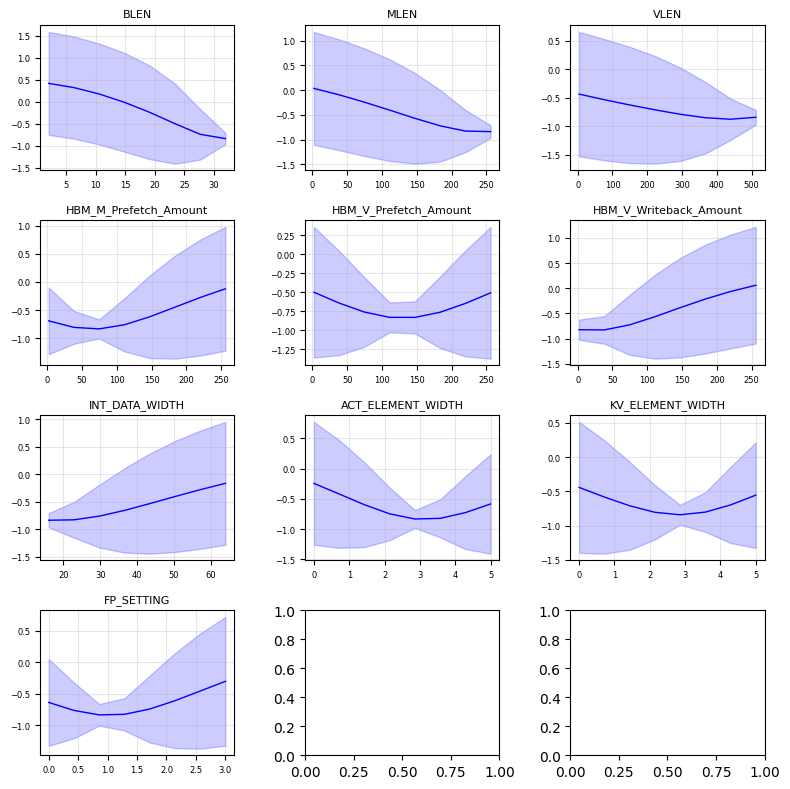

In [150]:
import matplotlib.pyplot as plt
import torch
import os

# Create output folder
os.makedirs("gp_slices", exist_ok=True)

def plot_all_gp_slices(model, base_point, n_dims=10):
    # Calculate grid layout (7x7 for 49 dimensions)
    cols = 3
    rows = 4
    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))  # Large figure
    
    # Flatten axes for easy iteration
    axes = axes.ravel()
    
    for dim in range(n_dims):
        x_min = train_X[:, dim].min().item()
        x_max = train_X[:, dim].max().item()
        x_range = torch.linspace(x_min, x_max, 8)
        # Create test points for this dimension
        test_X = base_point.repeat(8, 1)
        test_X[:, dim] = x_range
        
        # Get posterior
        with torch.no_grad():
            posterior = model.posterior(test_X)
            mean = posterior.mean.squeeze()
            # print(mean)
            lower, upper = posterior.confidence_region()
        
        # Plot on the corresponding subplot
        ax = axes[dim]
        ax.plot(x_range.numpy(), mean.numpy(), 'b-', linewidth=1)
        ax.fill_between(x_range.numpy(), lower.numpy(), upper.numpy(), 
                       color='blue', alpha=0.2)
        
        # Format subplot
        ax.set_title(feature_order[dim], fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=6)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save and show
    save_path = "gp_slices/all_dims_accuracy.png"
    # plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # print(f"[INFO] Saved combined GP slices to: {save_path}")

# Find best point to use as base for slicing
best_idx = torch.argmin(train_Y)  # if minimizing
base_point = train_X[best_idx].clone().unsqueeze(0)

# Create the big combined plot
plot_all_gp_slices(model, base_point)

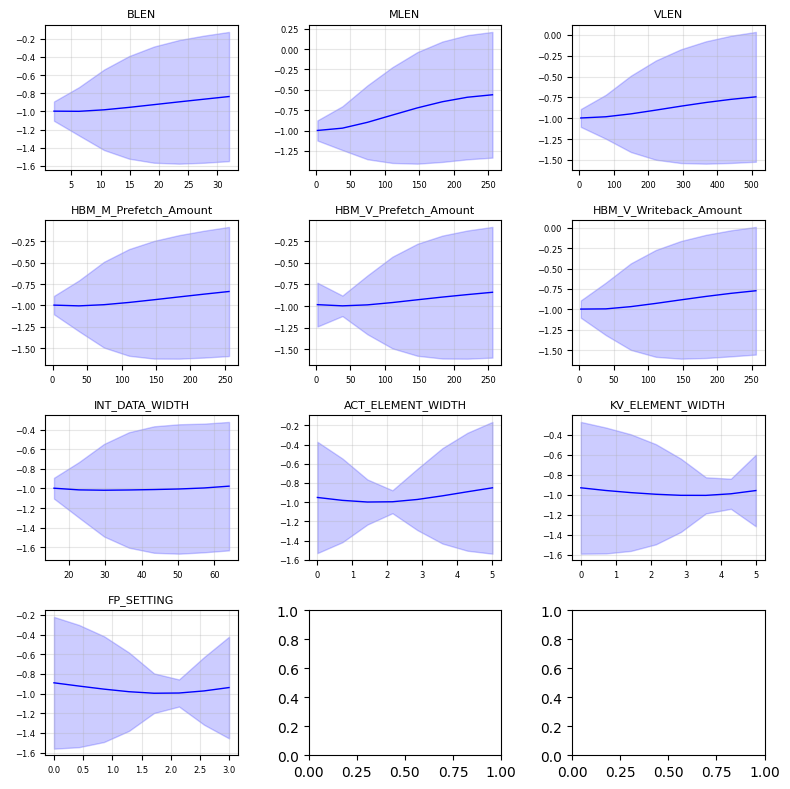

In [147]:
import matplotlib.pyplot as plt
import torch
import os

# Create output folder
os.makedirs("gp_slices", exist_ok=True)

def plot_all_gp_slices(model, base_point, n_dims=10):
    # Calculate grid layout (7x7 for 49 dimensions)
    cols = 3
    rows = 4
    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))  # Large figure
    
    # Flatten axes for easy iteration
    axes = axes.ravel()
    
    for dim in range(n_dims):
        x_min = train_X[:, dim].min().item()
        x_max = train_X[:, dim].max().item()
        x_range = torch.linspace(x_min, x_max, 8)
        # Create test points for this dimension
        test_X = base_point.repeat(8, 1)
        test_X[:, dim] = x_range
        
        # Get posterior
        with torch.no_grad():
            posterior = model.posterior(test_X)
            mean = posterior.mean.squeeze()
            # print(mean)
            lower, upper = posterior.confidence_region()
        
        # Plot on the corresponding subplot
        ax = axes[dim]
        ax.plot(x_range.numpy(), mean.numpy(), 'b-', linewidth=1)
        ax.fill_between(x_range.numpy(), lower.numpy(), upper.numpy(), 
                       color='blue', alpha=0.2)
        
        # Format subplot
        ax.set_title(feature_order[dim], fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=6)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save and show
    save_path = "gp_slices/all_dims_accuracy.png"
    # plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # print(f"[INFO] Saved combined GP slices to: {save_path}")

# Find best point to use as base for slicing
best_idx = torch.argmin(train_Y)  # if minimizing
base_point = train_X[best_idx].clone().unsqueeze(0)

# Create the big combined plot
plot_all_gp_slices(model, base_point)

In [141]:
train_X

tensor([[  8.,  32.,   8.,  32.,   8.,   4.,  16.,   1.,   2.,   0.],
        [  2.,   2., 128.,   8., 128.,  64.,  64.,   2.,   4.,   3.],
        [  8.,  32., 256.,  32.,   8.,  16.,  16.,   4.,   2.,   3.],
        [  2.,   4.,  32., 128., 128.,  32.,  64.,   3.,   3.,   0.],
        [ 32.,  32., 128.,  64.,  64., 256.,  64.,   2.,   4.,   0.],
        [  4.,  16.,   4.,  16., 128.,  16.,  16.,   3.,   2.,   3.],
        [  4., 128.,  16.,   8.,   8., 256.,  64.,   0.,   1.,   2.],
        [ 16.,  16.,  32.,   4.,   8.,  16.,  32.,   4.,   3.,   1.],
        [  8.,  16.,  64.,  64.,  64.,  64.,  16.,   0.,   4.,   1.],
        [  4.,  16., 256.,   8.,  16.,   2.,  32.,   3.,   4.,   3.],
        [  4.,   4.,  16., 128., 128., 256.,  16.,   1.,   4.,   0.],
        [  2.,   2.,   4.,   2., 256., 256.,  32.,   2.,   0.,   0.],
        [  8.,   8., 128.,   8.,   2., 256.,  16.,   3.,   4.,   2.],
        [  2.,   4.,  32., 128.,   4.,  32.,  16.,   3.,   2.,   1.],
        [  8., 128.,

RuntimeError: A single best trial cannot be retrieved from a multi-objective study. Consider using Study.best_trials to retrieve a list containing the best trials.

In [88]:
t

FrozenTrial(number=1, state=1, values=[-0.2614628191639401, 1.0, -1.0], datetime_start=datetime.datetime(2025, 8, 15, 20, 56, 44, 50095), datetime_complete=datetime.datetime(2025, 8, 15, 21, 3, 6, 841668), params={'BLEN': 8, 'MLEN': 32, 'VLEN': 8, 'HBM_M_Prefetch_Amount': 32, 'HBM_V_Prefetch_Amount': 8, 'HBM_V_Writeback_Amount': 4, 'ACT_ELEMENT_WIDTH': 'MXFP_E4M3', 'KV_ELEMENT_WIDTH': 'MXFP_E5M2', 'FP_SETTING': 'FP_E4M7', 'INT_DATA_WIDTH': 16}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 0}, intermediate_values={}, distributions={'BLEN': CategoricalDistribution(choices=(2, 4, 8, 16, 32)), 'MLEN': CategoricalDistribution(choices=(2, 4, 8, 16, 32, 64, 128, 256, 512)), 'VLEN': CategoricalDistribution(choices=(2, 4, 8, 16, 32, 64, 128, 256, 512, 1024)), 'HBM_M_Prefetch_Amount': CategoricalDistribution(choices=(2, 4, 8, 16, 32, 64, 128, 256)), 'HBM_V_Prefetch_Amount': CategoricalDistribution(choices=(2, 4, 8, 16, 32, 64, 128, 256)), 'HBM_V_Writeback_Amount': CategoricalDistribu

In [ ]:
t.params

{'BLEN': 8,
 'MLEN': 32,
 'VLEN': 8,
 'HBM_M_Prefetch_Amount': 32,
 'HBM_V_Prefetch_Amount': 8,
 'HBM_V_Writeback_Amount': 4,
 'ACT_ELEMENT_WIDTH': 'MXFP_E4M3',
 'KV_ELEMENT_WIDTH': 'MXFP_E5M2',
 'FP_SETTING': 'FP_E4M7',
 'INT_DATA_WIDTH': 16}

In [82]:
len(trials)

26